In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
import cv2
import fitz                          # PyMuPDF — PDF slide loading
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import re
from pathlib import Path
from types import SimpleNamespace
from scipy.ndimage import uniform_filter
from scipy.special import logsumexp


In [79]:
# ── Paths & constants ────────────────────────────────────────────────────────
VIDEO_PATH  = Path('data/query_planning.mp4')
PDF_PATH    = Path('data/query_planning.pdf')
TXT_PATH    = Path('data/query_planning.txt')

# Both frames and slides are resized to this shape before any comparison.
TARGET_SIZE  = (128, 128)   # (width, height) — cv2 convention
TARGET_W, TARGET_H = TARGET_SIZE

# Neighbourhood radius for per-pixel Gaussian MLE fitting.
# Each pixel's Gaussian is estimated from the (2R+1)×(2R+1) local window.
NEIGHBOR_RAD = 10

# HMM transition parameter.
# B = P(stay on same slide).  Jump prob = (1-B)/(N_slides - 1).
B = 0.999999


In [64]:
# ── Load timestamps from transcript .txt ─────────────────────────────────────
# The file produced by transcribe.py looks like:
#   [00:00:00.000 --> 00:00:03.440]
#   Some spoken text here.
#
# We parse it into a sorted list of SimpleNamespace objects with
# attributes  .start (float s)  .end (float s)  .text (str).

_TS_RE = re.compile(r'\[(\d{2}:\d{2}:\d{2}\.\d+) --> (\d{2}:\d{2}:\d{2}\.\d+)\]')

def ts_to_sec(ts: str) -> float:
    h, m, s = ts.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

segments = []
current_start = current_end = None
text_lines = []

with open(TXT_PATH, 'r') as fh:
    for line in fh:
        line = line.rstrip('\n')
        m = _TS_RE.match(line)
        if m:
            if current_start is not None and text_lines:
                segments.append(SimpleNamespace(
                    start=current_start, end=current_end,
                    text=' '.join(text_lines)
                ))
            current_start = ts_to_sec(m.group(1))
            current_end   = ts_to_sec(m.group(2))
            text_lines = []
        elif line.strip() and current_start is not None:
            text_lines.append(line.strip())

# flush last segment
if current_start is not None and text_lines:
    segments.append(SimpleNamespace(
        start=current_start, end=current_end,
        text=' '.join(text_lines)
    ))

# Guarantee chronological order
segments.sort(key=lambda s: s.start)

# The timestamps we will extract frames at
seg_times   = np.array([seg.start for seg in segments])   # (T,)
n_frames    = len(segments)

print(f'Parsed {n_frames} segments')
print(f'Time range: {seg_times[0]:.1f}s – {seg_times[-1]:.1f}s')


Parsed 757 segments
Time range: 0.0s – 5391.4s


In [65]:
# ── Load raw PDF slides ───────────────────────────────────────────────────────
# We load every page as a uint8 grayscale array resized to TARGET_SIZE.
# Normalization (mean/std scaling) is applied later in a shared pipeline
# so that slides and video frames are comparable in the same pixel space.

def load_pdf_slides_raw(pdf_path: Path):
    """Return a list of (H, W) uint8 grayscale arrays, one per PDF page."""
    raw = []
    pdf = fitz.open(str(pdf_path))
    for page in pdf:
        pix = page.get_pixmap(dpi=72)          # render at 72 dpi
        # pix.samples is a flat byte string in RGB order
        rgb = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)                # (H_page, W_page)
        resized = cv2.resize(gray, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)
        raw.append(resized)
    pdf.close()
    return raw

# slides_raw  : list of n_slides arrays, each (TARGET_H, TARGET_W) uint8
slides_raw = load_pdf_slides_raw(PDF_PATH)
n_slides   = len(slides_raw)

print(f'Loaded {n_slides} PDF slides, each {TARGET_W}×{TARGET_H} px (before normalization)')


MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

Loaded 114 PDF slides, each 128×128 px (before normalization)


In [66]:
# ── AOI calibration + frame extraction ───────────────────────────────────────
#
# Stage 1 — AOI calibration (temporary transform, discarded afterwards):
#   Sample 10 evenly-spaced frames from the video.
#   For each frame apply the double-pass Sobel + directional closing + Hough
#   pipeline to detect the upper-left corner (x, y) of the slide area.
#   Take the median x and median y as the stable crop corner.
#
# Stage 2 — Final frame extraction:
#   For every segment, extract the raw frame, apply the calibrated crop,
#   convert to grayscale, and resize to TARGET_SIZE.
#   The resulting uint8 arrays are kept separate from normalization.

# ─── helpers ────────────────────────────────────────────────────────────────

def _extract_frame_bgr(video_path: Path, timestamp: float):
    """Pull one full-resolution BGR frame via ffmpeg, return as numpy array."""
    cmd = [
        'ffmpeg', '-y', '-ss', str(timestamp), '-i', str(video_path),
        '-frames:v', '1', '-f', 'image2pipe', '-vcodec', 'png', 'pipe:1',
    ]
    result = subprocess.run(cmd, capture_output=True)
    if result.returncode != 0 or not result.stdout:
        return None
    arr = np.frombuffer(result.stdout, dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)   # BGR, full resolution


def _find_aoi_corner(frame_bgr, ksize=3, threshold=80, angle_tol=6):
    """
    Detect the upper-left corner of the slide region.

    Pipeline (temporary — result discarded after cropping):
      1. Grayscale + Gaussian blur
      2. Double-pass Sobel in x and y separately (2nd pass amplifies hard edges)
      3. Threshold to binary
      4. Directional morphological closing:
           tall (1×40) kernel bridges gaps in vertical edges
           wide (40×1) kernel bridges gaps in horizontal edges
      5. HoughLinesP — longest vertical line gives x_crop,
                        longest horizontal line gives y_crop

    Returns (x_crop, y_crop) or (None, None) if detection fails.
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Double-pass Sobel: 2nd pass on |1st pass| sharpens strong gradient peaks
    sx  = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=ksize)
    sy  = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=ksize)
    sx2 = cv2.Sobel(np.abs(sx), cv2.CV_64F, 1, 0, ksize=ksize)
    sy2 = cv2.Sobel(np.abs(sy), cv2.CV_64F, 0, 1, ksize=ksize)

    bx = cv2.threshold(cv2.convertScaleAbs(sx + 3 * sx2), threshold, 255, cv2.THRESH_BINARY)[1]
    by = cv2.threshold(cv2.convertScaleAbs(sy + 3 * sy2), threshold, 255, cv2.THRESH_BINARY)[1]

    # Close gaps along each edge direction separately
    k_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))   # vertical gaps
    k_h = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))   # horizontal gaps
    closed = cv2.bitwise_or(
        cv2.morphologyEx(bx, cv2.MORPH_CLOSE, k_v),
        cv2.morphologyEx(by, cv2.MORPH_CLOSE, k_h),
    )

    lines = cv2.HoughLinesP(closed, rho=1, theta=np.pi / 180, threshold=40,
                              minLineLength=40, maxLineGap=50)

    h_lines, v_lines = [], []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            length = np.hypot(x2 - x1, y2 - y1)
            if abs(y2 - y1) <= angle_tol:     # near-horizontal
                h_lines.append((length, line[0]))
            elif abs(x2 - x1) <= angle_tol:   # near-vertical
                v_lines.append((length, line[0]))

    h_lines.sort(key=lambda t: -t[0])
    v_lines.sort(key=lambda t: -t[0])

    x_crop = int((v_lines[0][1][0] + v_lines[0][1][2]) / 2) if v_lines else None
    y_crop = int((h_lines[0][1][1] + h_lines[0][1][3]) / 2) if h_lines else None
    return x_crop, y_crop


# ─── Stage 1: calibrate crop corner from 10 frames ──────────────────────────
calib_indices = np.linspace(0, n_frames - 1, 10, dtype=int)
calib_x, calib_y = [], []

print('Calibrating AOI corner from 10 evenly-spaced frames ...')
for idx in calib_indices:
    bgr = _extract_frame_bgr(VIDEO_PATH, segments[idx].start)
    if bgr is None:
        continue
    cx, cy = _find_aoi_corner(bgr)
    if cx is not None: calib_x.append(cx)
    if cy is not None: calib_y.append(cy)

# Robust corner estimate via median (outlier-resistant)
crop_x = int(np.median(calib_x)) if calib_x else 0
crop_y = int(np.median(calib_y)) if calib_y else 0
print(f'  -> stable crop corner: x={crop_x}, y={crop_y}')
print(f'     (measured from {len(calib_x)}/10 frames)')

# ─── Stage 2: extract all frames with that crop ──────────────────────────────
# Each entry in frames_raw is either:
#   - a (TARGET_H, TARGET_W) uint8 grayscale array (successful), or
#   - None  (ffmpeg failure for that timestamp)

print(f'Extracting {n_frames} frames (cropped + grayscaled + resized) ...')
frames_raw = []
for seg in segments:
    bgr = _extract_frame_bgr(VIDEO_PATH, seg.start)
    if bgr is None:
        frames_raw.append(None)
        continue
    h_full, w_full = bgr.shape[:2]
    roi     = bgr[crop_y:h_full, crop_x:w_full]                        # crop
    gray    = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)                     # grayscale
    resized = cv2.resize(gray, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)  # resize
    frames_raw.append(resized)

n_valid = sum(f is not None for f in frames_raw)
print(f'  -> {n_valid}/{n_frames} frames extracted successfully')


Calibrating AOI corner from 10 evenly-spaced frames ...
  -> stable crop corner: x=299, y=169
     (measured from 10/10 frames)
Extracting 757 frames (cropped + grayscaled + resized) ...
  -> 757/757 frames extracted successfully


In [67]:
# ── Normalize slides and frames ───────────────────────────────────────────────
# Both go through the same per-image z-score normalization:
#   pixel_out = (pixel_in - mean) / std
# This puts both in the same numerical scale and removes global brightness
# differences between the PDF rendering and the video capture.
#
# PDF slides: no crop (the full slide content is relevant).
# Video frames: already cropped to the slide area in the previous cell.

def normalize_gray(uint8_arr: np.ndarray) -> np.ndarray:
    """Convert a uint8 grayscale image to float32 z-scores (mean 0, std 1)."""
    arr  = uint8_arr.astype(np.float32)
    mean = arr.mean()
    std  = arr.std()
    return (arr - mean) / (std if std > 0 else 1.0)

# slides_norm : (n_slides, TARGET_H, TARGET_W)  float32
slides_norm = np.stack([normalize_gray(s) for s in slides_raw], axis=0)

# frames_norm : list of (TARGET_H, TARGET_W) float32, or None
frames_norm = [
    normalize_gray(f) if f is not None else None
    for f in frames_raw
]

print(f'slides_norm shape : {slides_norm.shape}   (n_slides, H, W)')
print(f'frames_norm       : {len(frames_norm)} entries  ({n_valid} valid)')
print(f'  slide pixel range (slide 0): [{slides_norm[0].min():.2f}, {slides_norm[0].max():.2f}]')


slides_norm shape : (114, 128, 128)   (n_slides, H, W)
frames_norm       : 757 entries  (757 valid)
  slide pixel range (slide 0): [-1.73, 1.38]


In [68]:
# ── Fit per-pixel Gaussian models for each slide ─────────────────────────────
#
# For slide s and pixel (y, x) we model the expected pixel value as
#   P(v | slide=s, pos=(y,x)) = N( v ; μ_{s,y,x}, σ_{s,y,x} )
#
# MLE estimates from the local (2R+1)×(2R+1) neighbourhood:
#   μ_{s,y,x} = mean  of slide_s pixels in the window
#   σ_{s,y,x} = std   of slide_s pixels in the window
#
# Border pixels naturally have a smaller valid window — we handle this
# correctly WITHOUT padding by:
#   1. Running uniform_filter with mode='constant', cval=0 (zero-pad).
#      This pads the array with zeros before averaging.
#   2. Running the same filter on an all-ones array to count valid pixels.
#   3. Correcting the mean:  local_mean = (padded_mean * WIN²) / valid_count
#
# This gives the true mean/std over only the valid in-image neighbours
# without introducing any padding bias.

WIN_SIZE = 2 * NEIGHBOR_RAD + 1   # 21 × 21 window

# valid_count[y, x] = number of pixels that actually lie inside the image
# for the window centred at (y, x).  Computed once, shared across slides.
_ones_hw     = np.ones((TARGET_H, TARGET_W), dtype=np.float32)
valid_count  = uniform_filter(_ones_hw, size=WIN_SIZE, mode='constant', cval=0) * (WIN_SIZE ** 2)
# valid_count is (H, W) float32, values in [1, WIN_SIZE²]

# Pre-allocate parameter arrays
#   slide_mu    [s, y, x]  — local mean for slide s at pixel (y, x)
#   slide_sigma [s, y, x]  — local std  for slide s at pixel (y, x)  (>0)
slide_mu    = np.zeros((n_slides, TARGET_H, TARGET_W), dtype=np.float32)
slide_sigma = np.zeros((n_slides, TARGET_H, TARGET_W), dtype=np.float32)

print(f'Fitting Gaussian models: {n_slides} slides × {TARGET_H}×{TARGET_W} pixels ...')
for s_idx in range(n_slides):
    s = slides_norm[s_idx]   # (H, W) float32

    # Sum of pixel values across the valid window (zero-padded sum / WIN² * WIN² = sum)
    local_sum    = uniform_filter(s,    size=WIN_SIZE, mode='constant', cval=0) * (WIN_SIZE ** 2)
    local_sq_sum = uniform_filter(s**2, size=WIN_SIZE, mode='constant', cval=0) * (WIN_SIZE ** 2)

    mu      = local_sum    / valid_count           # E[X]
    sq_mean = local_sq_sum / valid_count           # E[X²]
    var     = np.maximum(sq_mean - mu ** 2, 0)    # Var = E[X²] − E[X]², clamp ≥ 0
    sigma   = np.sqrt(var) + 1e-6                 # σ > 0 always

    slide_mu[s_idx]    = mu
    slide_sigma[s_idx] = sigma

print('  done.')
print(f'slide_mu    : {slide_mu.shape}   σ range (slide 0): [{slide_sigma[0].min():.4f}, {slide_sigma[0].max():.4f}]')


Fitting Gaussian models: 114 slides × 128×128 pixels ...
  done.
slide_mu    : (114, 128, 128)   σ range (slide 0): [0.0000, 1.2356]


In [69]:
# ── Log emission probabilities ────────────────────────────────────────────────
#
# For frame t and slide s:
#
#   log P(frame_t | slide_s)
#     = Σ_{y,x} log N( frame_t[y,x] ; μ_{s,y,x}, σ_{s,y,x} )
#     = Σ_{y,x} [ -½ log(2π) − log σ_{s,y,x} − ½ z_{s,y,x}² ]
#   where  z_{s,y,x} = (frame_t[y,x] − μ_{s,y,x}) / σ_{s,y,x}
#
# After computing the raw log-likelihood for all slides at time t we
# normalise across slides using log-sum-exp.  This is equivalent to applying
# a uniform slide prior and gives log P(slide_s | frame_t).
# The overall scale cancels in the forward-backward pass, so the posterior
# is unaffected by this normalisation choice.
#
# The inner sum is vectorised over all slides at once via broadcasting:
#   frame[None]  shape (1, H, W)  broadcasts against (n_slides, H, W).

_LOG2PI = float(np.log(2 * np.pi))   # constant term

# Precompute log σ for all slides — used in every frame evaluation
log_sigma = np.log(slide_sigma)   # (n_slides, H, W)

# log_emit[t, s] = normalised log P(slide_s | frame_t)
log_emit = np.full((n_frames, n_slides), -np.inf, dtype=np.float64)

print(f'Computing emission matrix ({n_frames} frames × {n_slides} slides) ...')
for t, frame in enumerate(frames_norm):
    if frame is None:
        # Failed frame: assign uniform emission (no information)
        log_emit[t, :] = -np.log(n_slides)
        continue

    # z-score of the frame pixel under each slide's Gaussian — (n_slides, H, W)
    z = (frame[np.newaxis] - slide_mu) / slide_sigma

    # Pixelwise log-Gaussian density, summed across all pixels — (n_slides,)
    log_raw = np.sum(
        -0.5 * (_LOG2PI + 2 * log_sigma + z ** 2),
        axis=(1, 2)
    )

    # Normalise across slides: subtract log Σ_s exp(log_raw[s])
    log_emit[t, :] = log_raw - logsumexp(log_raw)

print('  done.')
print(f'log_emit shape : {log_emit.shape}')
# Sanity: each row should be a valid log-probability distribution
row_sums = np.exp(log_emit).sum(axis=1)
print(f'  row sum check — min: {row_sums.min():.6f}  max: {row_sums.max():.6f}  (should be 1)')


Computing emission matrix (757 frames × 114 slides) ...
  done.
log_emit shape : (757, 114)
  row sum check — min: 1.000000  max: 1.000000  (should be 1)


In [80]:
# ── Transition matrix ─────────────────────────────────────────────────────────
#
# T[s, s'] = P(next slide = s' | current slide = s)
#
#   T[s, s']  =  B             if s == s'    (stay on same slide)
#   T[s, s']  =  (1-B)/(N-1)  if s != s'    (jump uniformly to any other)
#
# The matrix is symmetric and each row sums to 1.
# We store both the linear matrix T (for inspection) and
# log_T (for numerically stable log-space computations).

def make_transition_matrix(n: int, b: float) -> np.ndarray:
    """Build the (n × n) slide transition matrix for parameter b."""
    T = np.full((n, n), (1.0 - b) / (n - 1), dtype=np.float64)
    np.fill_diagonal(T, b)
    return T

T      = make_transition_matrix(n_slides, B)   # (n_slides, n_slides)
log_T  = np.log(T)                             # log-space version

print(f'Transition matrix (B={B}, N={n_slides})')
print(f'  Stay probability  (diagonal)  : {T[0, 0]:.4f}')
print(f'  Jump probability  (off-diag)  : {T[0, 1]:.6f}')
print(f'  Row sums (all should be 1.0)  : min={T.sum(axis=1).min():.8f}  max={T.sum(axis=1).max():.8f}')


Transition matrix (B=0.999999, N=114)
  Stay probability  (diagonal)  : 1.0000
  Jump probability  (off-diag)  : 0.000000
  Row sums (all should be 1.0)  : min=1.00000000  max=1.00000000


In [81]:
# ── Forward pass ──────────────────────────────────────────────────────────────
#
# Computes  α[t, s] = log P(o_0 … o_t , q_t = s)
#
# Initialisation (t = 0):
#   α[0, s] = log π[s] + log P(o_0 | s)
#   where π[s] = 1/N  (uniform initial distribution)
#
# Recursion (t = 1 … T-1):
#   α[t, s] = log P(o_t | s)
#             + log Σ_{s'} exp( α[t-1, s'] + log T[s', s] )
#
# The inner log-sum-exp is computed as:
#   trans_contrib[s', s] = α[t-1, s'] + log T[s', s]   shape (N, N)
#   logsumexp over axis 0 (sum over source state s') → shape (N,)

log_pi    = np.full(n_slides, -np.log(n_slides), dtype=np.float64)   # uniform prior
log_alpha = np.zeros((n_frames, n_slides), dtype=np.float64)

# t = 0: initialise with prior and first observation
log_alpha[0] = log_pi + log_emit[0]

# t = 1 … T-1: recurse
for t in range(1, n_frames):
    # Expand α[t-1] to (N, 1) so it broadcasts with log_T (N, N)
    # Result[s', s] = α[t-1, s'] + log T[s', s]
    trans_contrib = log_alpha[t - 1, :, np.newaxis] + log_T   # (N, N)

    # Sum over source states s' → (N,); then add observation likelihood
    log_alpha[t]  = logsumexp(trans_contrib, axis=0) + log_emit[t]

# The total log-likelihood of all observations
log_likelihood = logsumexp(log_alpha[-1])

print(f'log_alpha shape : {log_alpha.shape}')
print(f'log P(all observations) = {log_likelihood:.2f} nats')


log_alpha shape : (757, 114)
log P(all observations) = -2749.09 nats


In [82]:
# ── Backward pass ─────────────────────────────────────────────────────────────
#
# Computes  β[t, s] = log P(o_{t+1} … o_{T-1} | q_t = s)
#
# Initialisation (t = T-1):
#   β[T-1, s] = log 1 = 0   for all s
#
# Recursion (t = T-2 … 0):
#   β[t, s] = log Σ_{s'} exp( log T[s, s'] + log P(o_{t+1} | s') + β[t+1, s'] )
#
# Here log_T[s, s'] + log_emit[t+1] + log_beta[t+1]  has shape (N, N):
#   log_T         : (N, N)  — T[s, s']
#   log_emit[t+1] : (N,)    — broadcasts to add along the s' axis
#   log_beta[t+1] : (N,)    — broadcasts to add along the s' axis
# logsumexp over axis 1 (sum over target states s') → shape (N,)

log_beta = np.zeros((n_frames, n_slides), dtype=np.float64)   # initialised to log(1)=0

for t in range(n_frames - 2, -1, -1):
    # contrib[s, s'] = log T[s, s'] + log P(o_{t+1} | s') + β[t+1, s']
    contrib     = log_T + log_emit[t + 1] + log_beta[t + 1]   # (N, N)
    log_beta[t] = logsumexp(contrib, axis=1)                   # sum over s'

print(f'log_beta shape : {log_beta.shape}')


log_beta shape : (757, 114)


In [83]:
# ── Posterior (gamma) ─────────────────────────────────────────────────────────
#
# γ[t, s] = P(q_t = s | o_0 … o_{T-1})
#          ∝ α[t, s] · β[t, s]
#
# In log space:
#   log γ[t, s]  =  log α[t, s] + log β[t, s]  − log P(o_0 … o_{T-1})
#
# We normalise each time step independently using logsumexp so that
# Σ_s γ[t, s] = 1 for every t.

# Unnormalised log joint
log_gamma_raw = log_alpha + log_beta                               # (T, N)

# Normalise row-wise: subtract the per-row log partition function
log_gamma = log_gamma_raw - logsumexp(log_gamma_raw, axis=1, keepdims=True)

# Convert to probability space
posterior = np.exp(log_gamma)   # (T, N)  — P(slide | all observations)

# Most-likely slide at each time step (greedy argmax of the posterior)
most_likely_slide = np.argmax(posterior, axis=1) + 1   # 1-based

# Sanity checks
row_sums = posterior.sum(axis=1)
print(f'posterior shape    : {posterior.shape}')
print(f'row sum check      : min={row_sums.min():.8f}  max={row_sums.max():.8f}  (should be 1)')
print(f'most_likely_slide (first 10): {most_likely_slide[:10]}')


posterior shape    : (757, 114)
row sum check      : min=1.00000000  max=1.00000000  (should be 1)
most_likely_slide (first 10): [ 24  24  24  24  24  24  24 102 102  53]


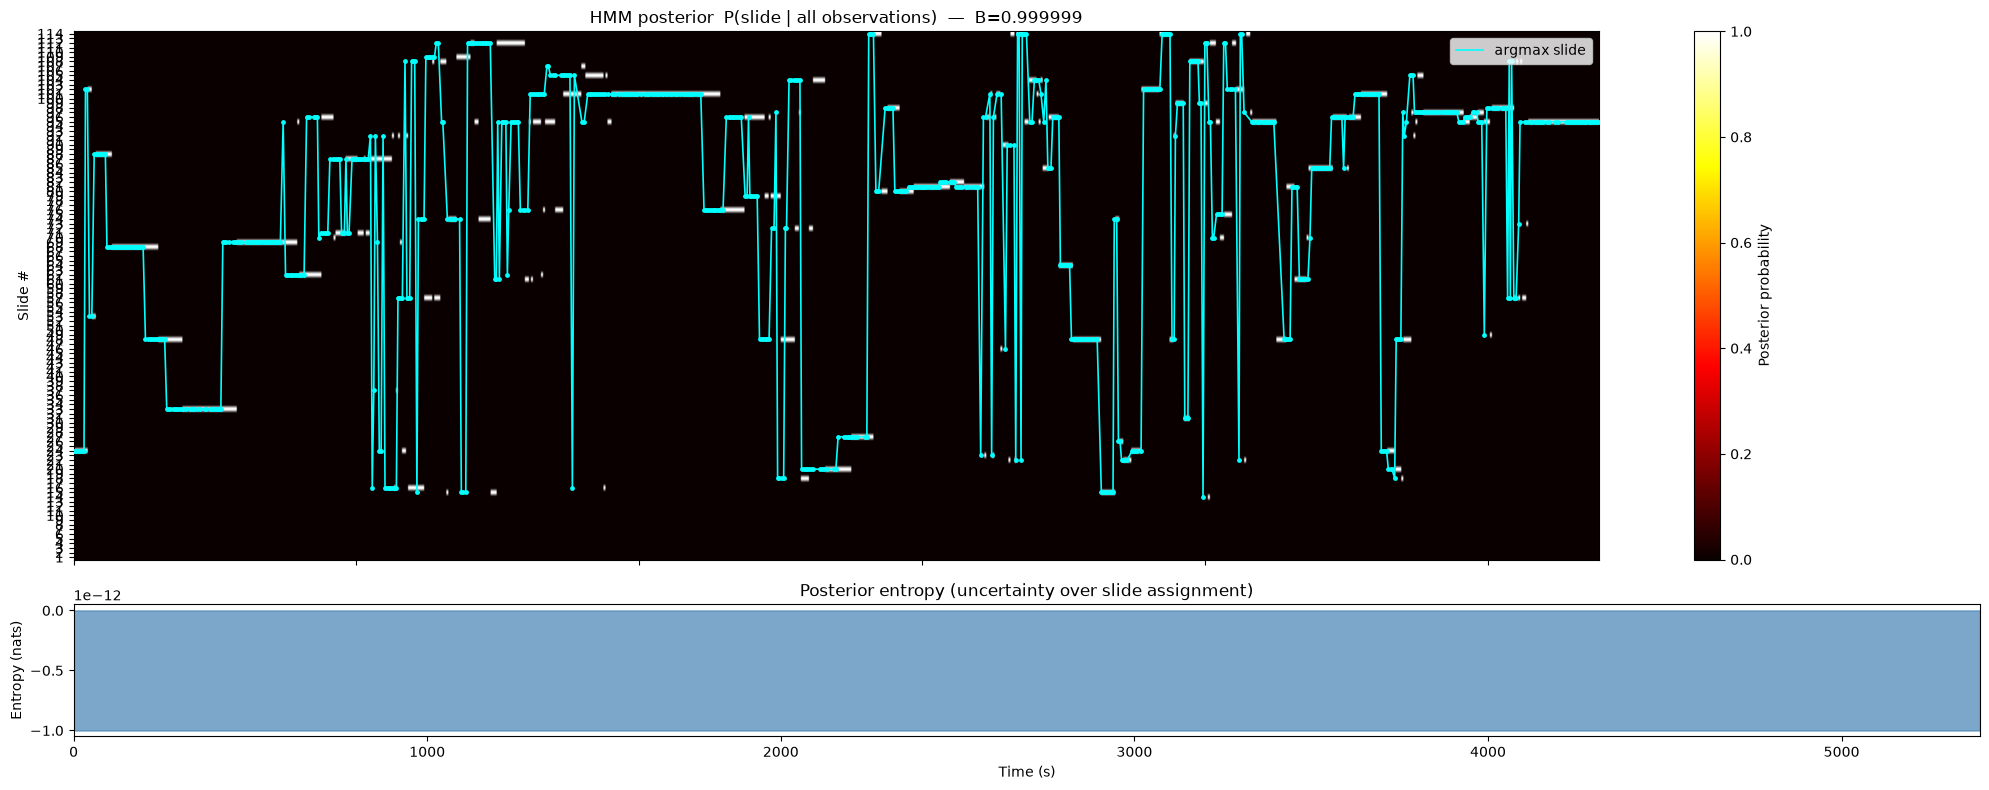

In [84]:
# ── Visualisation: posterior heatmap ──────────────────────────────────────────
#
# Each column of the heatmap is a probability distribution over slides
# at one point in time.  Hot colours = high posterior probability.
# The cyan dots show the argmax slide at each timestamp.

fig, axes = plt.subplots(
    2, 1,
    figsize=(20, 8),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True,
)

# ── Top panel: full posterior heatmap ────────────────────────────────────────
ax = axes[0]

# posterior.T  shape (n_slides, n_frames)  — rows = slides, cols = time
im = ax.imshow(
    posterior.T,
    aspect='auto',
    origin='lower',              # slide 1 at bottom, slide N at top
    cmap='hot',
    vmin=0, vmax=1,
    extent=[seg_times[0], seg_times[-1], 0.5, n_slides + 0.5],
)

# Overlay the argmax path in cyan
ax.plot(seg_times, most_likely_slide, color='cyan', lw=1.2,
        label='argmax slide', zorder=3)
ax.scatter(seg_times, most_likely_slide, color='cyan', s=6, zorder=4)

ax.set_ylabel('Slide #')
ax.set_yticks(range(1, n_slides + 1))
ax.set_title(f'HMM posterior  P(slide | all observations)  —  B={B}')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Posterior probability')

# ── Bottom panel: entropy over time (uncertainty) ────────────────────────────
# High entropy ≈ uncertain which slide; low entropy ≈ confident assignment.
entropy = -np.sum(posterior * np.log(posterior + 1e-12), axis=1)   # (T,)

axes[1].fill_between(seg_times, entropy, alpha=0.7, color='steelblue')
axes[1].set_ylabel('Entropy (nats)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Posterior entropy (uncertainty over slide assignment)')

plt.tight_layout()
plt.show()


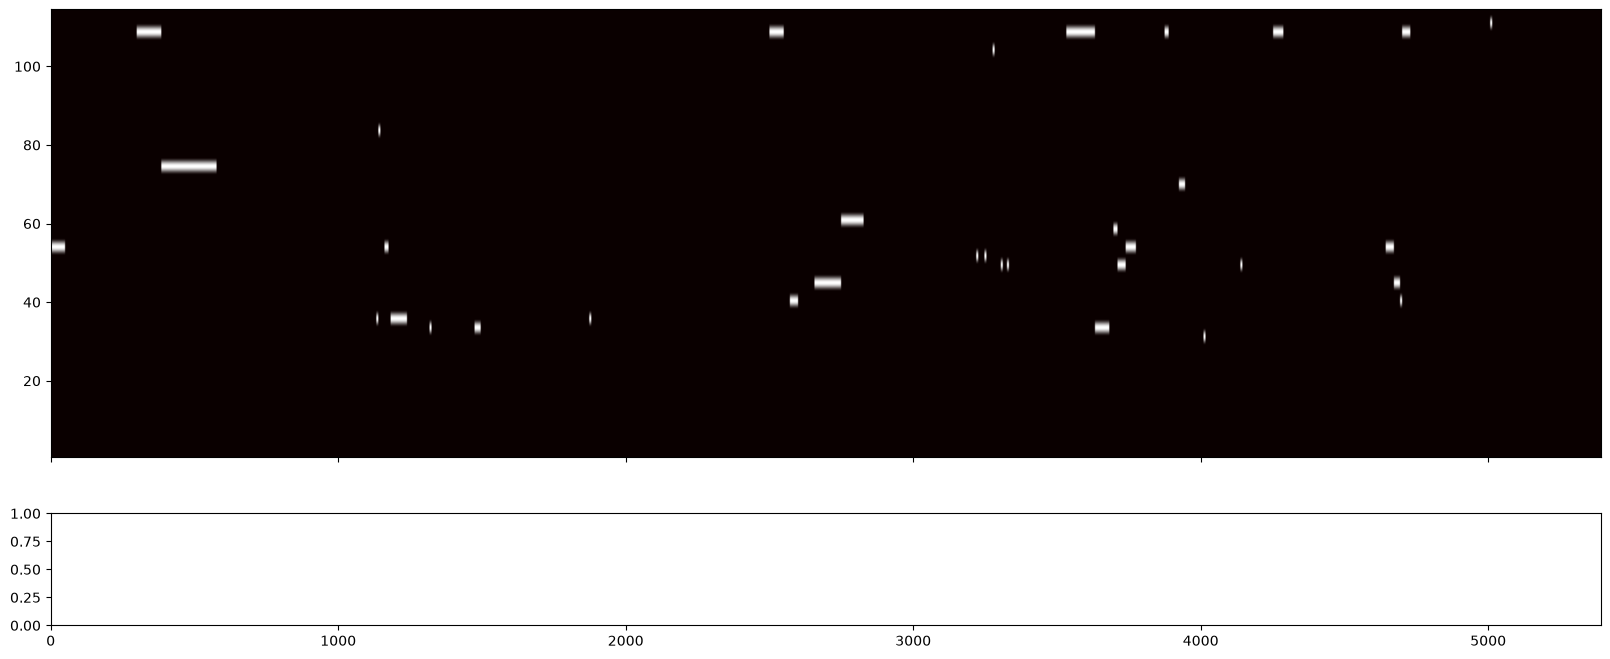

In [85]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(20, 8),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True,
)

# ── Top panel: full posterior heatmap ────────────────────────────────────────
ax = axes[0]

# posterior.T  shape (n_slides, n_frames)  — rows = slides, cols = time
im = ax.imshow(
    posterior.T[:50],
    aspect='auto',
    origin='lower',              # slide 1 at bottom, slide N at top
    cmap='hot',
    vmin=0, vmax=1,
    extent=[seg_times[0], seg_times[-1], 0.5, n_slides + 0.5],
)

In [86]:

def check_dirac(a):
    for i in a:
        if i == 1.0:
            return True
    return False

In [87]:
alter = []
for a in posterior:
    if not check_dirac(a):
        alter = a

In [88]:
alter

[]